In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [11]:
import os
import itertools
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device} | GPU Count: {torch.cuda.device_count()}")

# Checkpoints save karne ke liye folder bana lein
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "cyclegan_checkpoint.pth")

Using Device: cuda | GPU Count: 2


In [12]:
BATCH_SIZE = 8          # Speed ke liye 8
IMG_SIZE = 128          # Speed ke liye 128x128
EPOCHS = 20            # 10 se badha kar 40 kar diya best results ke liye
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_CYCLE = 10.0
LAMBDA_ID = 5.0
MAX_CLASSES = 2         

# Paths 
PHOTO_PATH = "/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/photo"
SKETCH_PATH = "/kaggle/input/datasets/ankitsheoran23/sketch-to-image/256x256/sketch"

In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features)
        )
    def forward(self, x): return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, num_residual_blocks=6):
        super(Generator, self).__init__()
        model = [nn.ReflectionPad2d(3), nn.Conv2d(3, 64, 7), nn.InstanceNorm2d(64), nn.ReLU(inplace=True)]
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [nn.Conv2d(in_features, out_features, 3, stride=2, padding=1), nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features * 2
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(in_features)]
        out_features = in_features // 2
        for _ in range(2):
            model += [nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1), nn.InstanceNorm2d(out_features), nn.ReLU(inplace=True)]
            in_features = out_features
            out_features = in_features // 2
        model += [nn.ReflectionPad2d(3), nn.Conv2d(64, 3, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)
    def forward(self, x): return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, padding=1), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, padding=1)
        )
    def forward(self, x): return self.model(x)

In [14]:
class NestedCycleGANDataset(Dataset):
    def __init__(self, p_root, s_root, max_classes=2):
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5), # Data Augmentation: Overfitting rokne ke liye
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
        all_classes = set()
        for tx in os.listdir(p_root):
            tx_path = os.path.join(p_root, tx)
            if os.path.isdir(tx_path):
                for cls in os.listdir(tx_path):
                    if os.path.isdir(os.path.join(tx_path, cls)): all_classes.add(cls)
        
        self.selected_classes = sorted(list(all_classes))[:max_classes]

        def collect_files(root_dir):
            paths = []
            for tx in os.listdir(root_dir):
                tx_path = os.path.join(root_dir, tx)
                if not os.path.isdir(tx_path): continue
                for cls in self.selected_classes:
                    cls_path = os.path.join(tx_path, cls)
                    if os.path.exists(cls_path):
                        for f in os.listdir(cls_path):
                            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                                paths.append(os.path.join(cls_path, f))
            return paths

        self.photo_files = collect_files(p_root)
        self.sketch_files = collect_files(s_root)
        # Max length use kar rahe hain taake dono datasets poore use hon
        self.length = max(len(self.photo_files), len(self.sketch_files))

    def __len__(self): return self.length
    
    def __getitem__(self, idx):
        # Modulo (%) operator ensure karta hai ke chota dataset (photos) cycle hota rahe
        p_img = Image.open(self.photo_files[idx % len(self.photo_files)]).convert("RGB")
        s_img = Image.open(self.sketch_files[idx % len(self.sketch_files)]).convert("RGB")
        return self.transform(s_img), self.transform(p_img)

dataset = NestedCycleGANDataset(PHOTO_PATH, SKETCH_PATH, max_classes=MAX_CLASSES)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f"Ready! Classes: {dataset.selected_classes} | Photos: {len(dataset.photo_files)} | Sketches: {len(dataset.sketch_files)}")

Ready! Classes: ['airplane', 'alarm_clock'] | Photos: 400 | Sketches: 7680


In [15]:
G_AB = Generator().to(device)
G_BA = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

if torch.cuda.device_count() > 1:
    G_AB = nn.DataParallel(G_AB)
    G_BA = nn.DataParallel(G_BA)
    D_A = nn.DataParallel(D_A)
    D_B = nn.DataParallel(D_B)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=LR, betas=(BETA1, BETA2))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=LR, betas=(BETA1, BETA2))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=LR, betas=(BETA1, BETA2))

# AMP Scaler for faster training on GPU
scaler = torch.cuda.amp.GradScaler()

start_epoch = 0

# Checkpoint Loading Logic
if os.path.exists(CHECKPOINT_PATH):
    print("Checkpoint found! Loading weights to resume training...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    
    G_AB.load_state_dict(checkpoint['G_AB'])
    G_BA.load_state_dict(checkpoint['G_BA'])
    D_A.load_state_dict(checkpoint['D_A'])
    D_B.load_state_dict(checkpoint['D_B'])
    
    optimizer_G.load_state_dict(checkpoint['optimizer_G'])
    optimizer_D_A.load_state_dict(checkpoint['optimizer_D_A'])
    optimizer_D_B.load_state_dict(checkpoint['optimizer_D_B'])
    
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from Epoch {start_epoch+1}")
else:
    print("No checkpoint found. Starting training from scratch.")

/tmp/ipykernel_478504/4199281891.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Checkpoint found! Loading weights to resume training...
Resuming from Epoch 19


In [16]:
print("Starting Full Training...")

for epoch in range(start_epoch, EPOCHS):
    epoch_start_time = time.time()
    
    # Loss accumulators
    total_loss_G, total_loss_D = 0.0, 0.0
    total_loss_cycle, total_loss_id, total_loss_adv = 0.0, 0.0, 0.0
    
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    steps = 0
    
    for i, (real_A, real_B) in enumerate(progress_bar):
        steps += 1
            
        real_A, real_B = real_A.to(device), real_B.to(device)
        
        # Dynamic label matching
        out_shape = D_A(real_A).shape[2:] 
        valid = torch.ones((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)
        fake = torch.zeros((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)

        # ------------------
        # Train Generators
        # ------------------
        optimizer_G.zero_grad()
        with torch.cuda.amp.autocast(): # Mixed precision
            loss_id_A = criterion_identity(G_BA(real_A), real_A)
            loss_id_B = criterion_identity(G_AB(real_B), real_B)
            loss_id = (loss_id_A + loss_id_B) / 2
            
            fake_B = G_AB(real_A)
            loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
            
            fake_A = G_BA(real_B)
            loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
            
            loss_adv = (loss_GAN_AB + loss_GAN_BA) / 2
            
            loss_cycle_A = criterion_cycle(G_BA(fake_B), real_A)
            loss_cycle_B = criterion_cycle(G_AB(fake_A), real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) / 2
            
            loss_G = loss_adv + (LAMBDA_CYCLE * loss_cycle) + (LAMBDA_ID * loss_id)

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)

        # ----------------------
        # Train Discriminators
        # ----------------------
        optimizer_D_A.zero_grad()
        with torch.cuda.amp.autocast():
            loss_D_A = (criterion_GAN(D_A(real_A), valid) + criterion_GAN(D_A(fake_A.detach()), fake)) / 2
        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)

        optimizer_D_B.zero_grad()
        with torch.cuda.amp.autocast():
            loss_D_B = (criterion_GAN(D_B(real_B), valid) + criterion_GAN(D_B(fake_B.detach()), fake)) / 2
        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)
        
        scaler.update()

        # Update accumulators
        loss_D = (loss_D_A + loss_D_B) / 2
        total_loss_G += loss_G.item()
        total_loss_D += loss_D.item()
        total_loss_adv += loss_adv.item()
        total_loss_cycle += loss_cycle.item()
        total_loss_id += loss_id.item()

        progress_bar.set_postfix(G_loss=f"{loss_G.item():.4f}", D_loss=f"{loss_D.item():.4f}")

    # Epoch Summary & Timing
    epoch_duration = time.time() - epoch_start_time
    epochs_left = EPOCHS - (epoch + 1)
    estimated_time_left = (epoch_duration * epochs_left) / 60 # In minutes
    
    print(f"\n--- Epoch [{epoch+1}/{EPOCHS}] Summary ---")
    print(f" Time Taken: {epoch_duration:.2f} sec | Estimated Time Left: {estimated_time_left:.2f} mins")
    print(f" Average Losses -> G: {total_loss_G/steps:.4f} | D: {total_loss_D/steps:.4f}")
    print(f"   ↳ Adversarial: {total_loss_adv/steps:.4f} | Cycle: {total_loss_cycle/steps:.4f} | Identity: {total_loss_id/steps:.4f}\n")

    # Save Checkpoint
    checkpoint_dict = {
        'epoch': epoch,
        'G_AB': G_AB.state_dict(),
        'G_BA': G_BA.state_dict(),
        'D_A': D_A.state_dict(),
        'D_B': D_B.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D_A': optimizer_D_A.state_dict(),
        'optimizer_D_B': optimizer_D_B.state_dict()
    }
    torch.save(checkpoint_dict, CHECKPOINT_PATH)
    print(" Checkpoint Saved!")

print(" Training fully completed!")

Starting Full Training...


Epoch 19/20:   0%|          | 0/960 [00:00<?, ?it/s]

/tmp/ipykernel_478504/3300427709.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Mixed precision
/tmp/ipykernel_478504/3300427709.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_478504/3300427709.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



--- Epoch [19/20] Summary ---
 Time Taken: 460.25 sec | Estimated Time Left: 7.67 mins
 Average Losses -> G: 1.6146 | D: 0.0553
   ↳ Adversarial: 0.8649 | Cycle: 0.0583 | Identity: 0.0334

 Checkpoint Saved!


Epoch 20/20:   0%|          | 0/960 [00:00<?, ?it/s]


--- Epoch [20/20] Summary ---
 Time Taken: 462.89 sec | Estimated Time Left: 0.00 mins
 Average Losses -> G: 1.5957 | D: 0.0498
   ↳ Adversarial: 0.8803 | Cycle: 0.0555 | Identity: 0.0321

 Checkpoint Saved!
 Training fully completed!


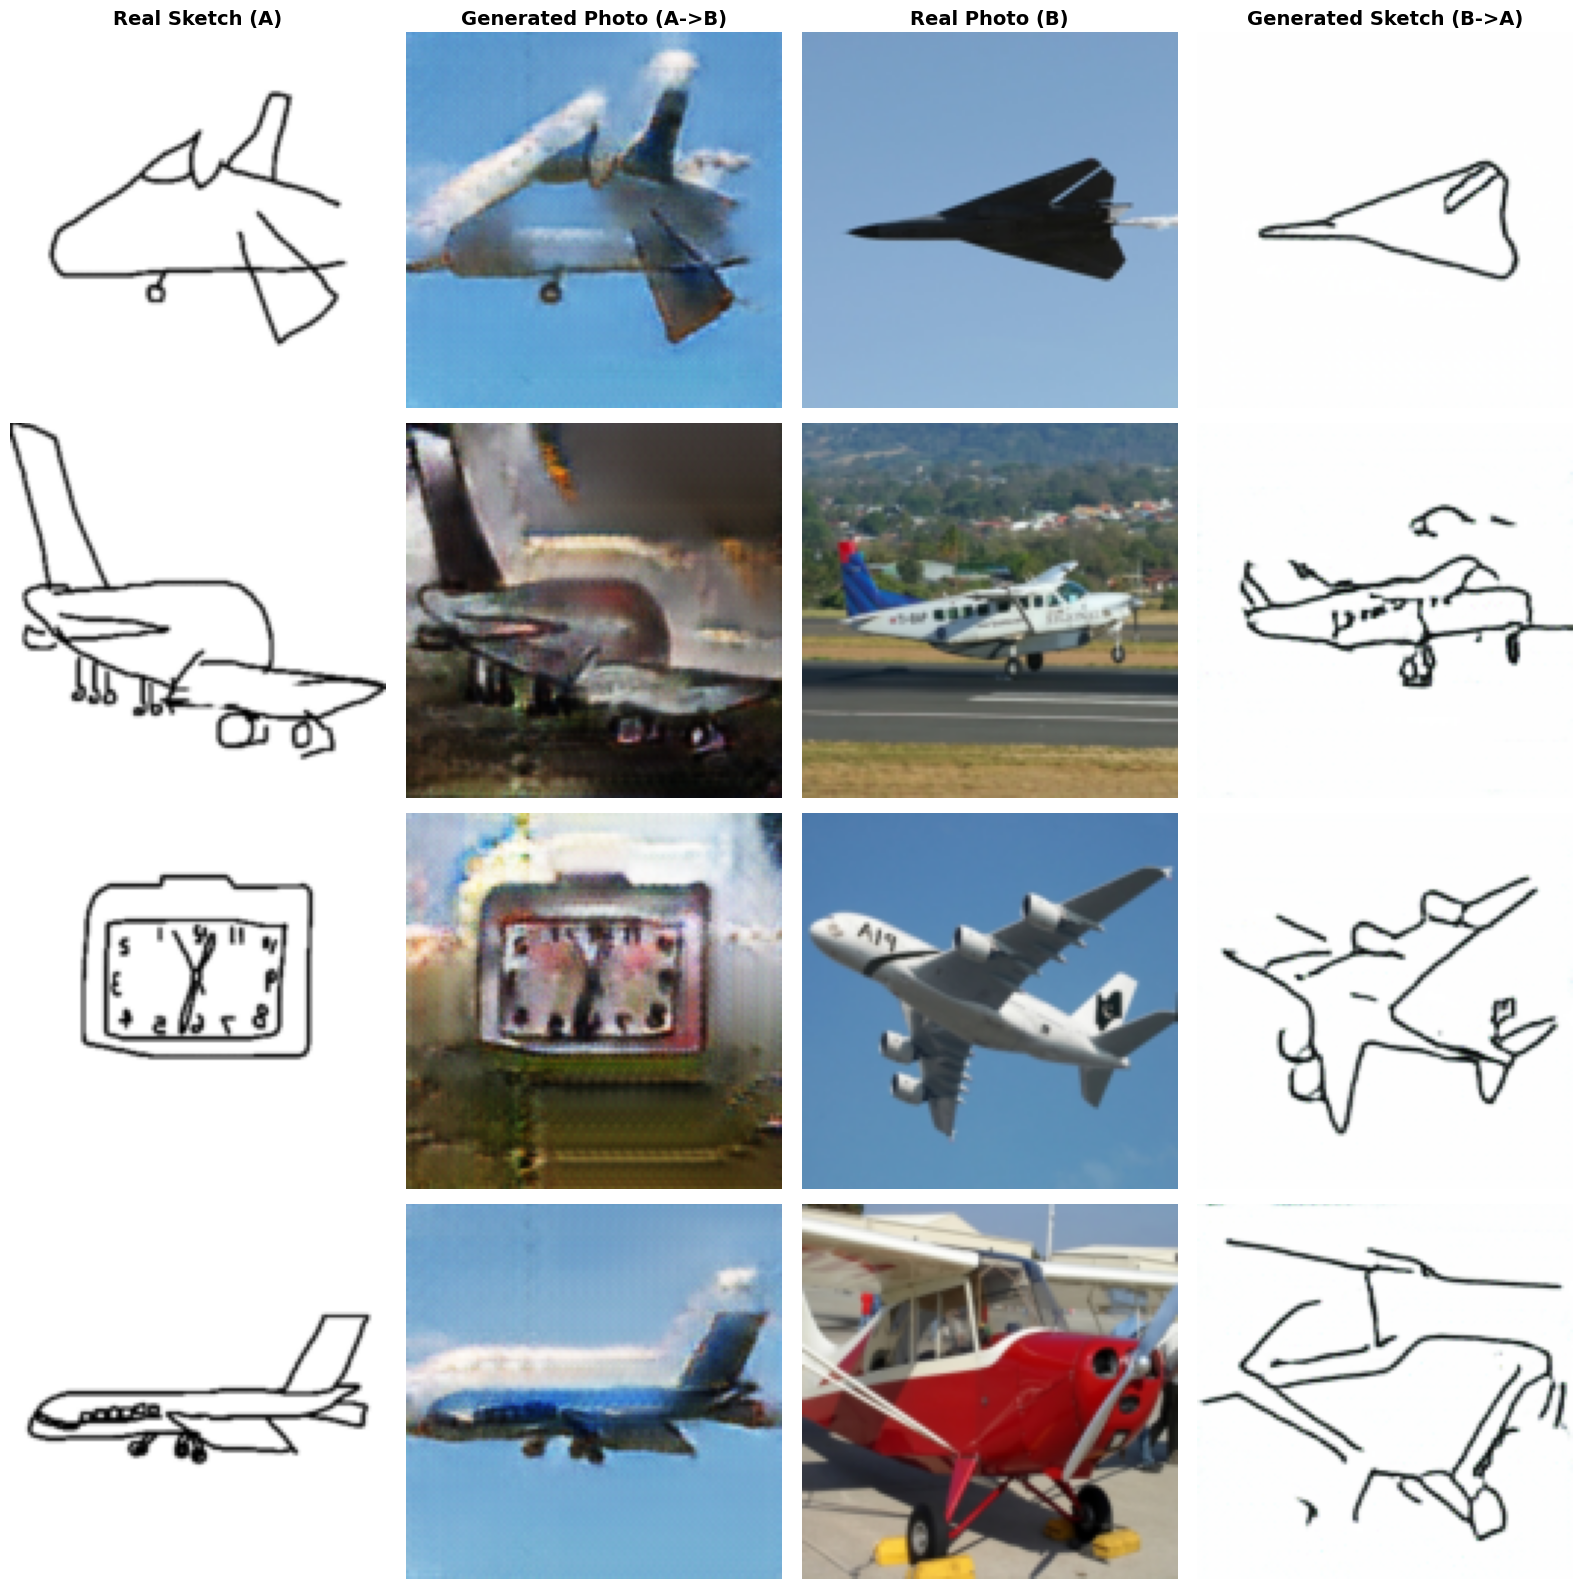

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_generated_results(num_samples=4):
    # Models ko evaluation mode mein daalein
    G_AB.eval()
    G_BA.eval()
    
    # Dataloader se ek random batch lein
    real_A, real_B = next(iter(loader))
    real_A = real_A.to(device)
    real_B = real_B.to(device)
    
    # Gradients calculate kiye bina images generate karein
    with torch.no_grad():
        with torch.amp.autocast('cuda'): 
            fake_B = G_AB(real_A)  # Sketch -> Photo
            fake_A = G_BA(real_B)  # Photo -> Sketch
        
    # Tensor ko image mein convert karne aur denormalize karne ka function
    def to_img(tensor):
        # .float() add kiya hai taake float16 ka masla hal ho jaye
        img = tensor.cpu().detach().float() 
        img = img * 0.5 + 0.5  # Denormalize
        img = torch.clamp(img, 0, 1) # Values ko 0-1 ke beech fix rakhein
        return img.permute(1, 2, 0).numpy()

    # Plotting ka setup
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    titles = ['Real Sketch (A)', 'Generated Photo (A->B)', 'Real Photo (B)', 'Generated Sketch (B->A)']
    
    for i in range(num_samples):
        # 1. Real Sketch
        ax = axes[i, 0] if num_samples > 1 else axes[0]
        ax.imshow(to_img(real_A[i]))
        if i == 0: ax.set_title(titles[0], fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 2. Generated Photo
        ax = axes[i, 1] if num_samples > 1 else axes[1]
        ax.imshow(to_img(fake_B[i]))
        if i == 0: ax.set_title(titles[1], fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 3. Real Photo
        ax = axes[i, 2] if num_samples > 1 else axes[2]
        ax.imshow(to_img(real_B[i]))
        if i == 0: ax.set_title(titles[2], fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # 4. Generated Sketch
        ax = axes[i, 3] if num_samples > 1 else axes[3]
        ax.imshow(to_img(fake_A[i]))
        if i == 0: ax.set_title(titles[3], fontsize=14, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    # Models ko wapas train mode mein daal dein
    G_AB.train()
    G_BA.train()

# Results show karein 
show_generated_results(num_samples=4)

In [ ]:
import os

print("Starting Full Training Loop (No Limits)...")

# Models save karne ke liye ek folder bana lete hain
os.makedirs("saved_models", exist_ok=True)

for epoch in range(EPOCHS):
    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for i, (real_A, real_B) in enumerate(progress_bar):
        
        # Yahan se limit hata di gayi hai taake poora data train ho
            
        real_A, real_B = real_A.to(device), real_B.to(device)
        
        # Dynamic label matching
        out_shape = D_A(real_A).shape[2:] 
        valid = torch.ones((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)
        fake = torch.zeros((real_A.size(0), 1, *out_shape), device=device, requires_grad=False)

        # ------------------
        # Train Generators
        # ------------------
        optimizer_G.zero_grad()
        loss_id = (criterion_identity(G_BA(real_A), real_A) + criterion_identity(G_AB(real_B), real_B)) / 2
        fake_B = G_AB(real_A); loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
        fake_A = G_BA(real_B); loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)
        loss_GAN = (loss_GAN_AB + loss_GAN_BA) / 2
        loss_cycle = (criterion_cycle(G_BA(fake_B), real_A) + criterion_cycle(G_AB(fake_A), real_B)) / 2
        loss_G = loss_GAN + LAMBDA_CYCLE * loss_cycle + LAMBDA_ID * loss_id
        loss_G.backward(); optimizer_G.step()

        # ------------------
        # Train Discriminators
        # ------------------
        optimizer_D_A.zero_grad()
        loss_D_A = (criterion_GAN(D_A(real_A), valid) + criterion_GAN(D_A(fake_A.detach()), fake)) / 2
        loss_D_A.backward(); optimizer_D_A.step()

        optimizer_D_B.zero_grad()
        loss_D_B = (criterion_GAN(D_B(real_B), valid) + criterion_GAN(D_B(fake_B.detach()), fake)) / 2
        loss_D_B.backward(); optimizer_D_B.step()

        progress_bar.set_postfix(G_loss=f"{loss_G.item():.4f}", D_loss=f"{(loss_D_A.item()+loss_D_B.item())/2:.4f}")

    # --- MODEL SAVING ---
    # Har epoch ke khatam hone par models save honge
    torch.save(G_AB.state_dict(), f"saved_models/G_AB_epoch_{epoch+1}.pth")
    torch.save(G_BA.state_dict(), f"saved_models/G_BA_epoch_{epoch+1}.pth")
    # Agar Discriminators bhi save karne hain (optional):
    torch.save(D_A.state_dict(), f"saved_models/D_A_epoch_{epoch+1}.pth")
    torch.save(D_B.state_dict(), f"saved_models/D_B_epoch_{epoch+1}.pth")
    
    print(f"\nModels successfully saved for Epoch {epoch+1} in 'saved_models' folder.")

print("Full Training finished!")

In [19]:
import os
import torch
import torch.nn as nn

# Model kahan save hoga
FINAL_MODEL_PATH = "/kaggle/working/cyclegan_final_generators.pth"

print("Saving final models for Gradio/Streamlit App...")

# DataParallel se weights nikalne ka safe tareeqa (taake normal laptop/PC par easily load ho sake)
def get_state_dict(model):
    if isinstance(model, nn.DataParallel):
        return model.module.state_dict()
    return model.state_dict()

# Hum sirf Generators save kar rahe hain kyun ke app banate waqt sirf inhi ki zaroorat hoti hai
final_weights = {
    'G_AB': get_state_dict(G_AB), # Sketch se Photo banane wala model
    'G_BA': get_state_dict(G_BA)  # Photo se Sketch banane wala model
}

torch.save(final_weights, FINAL_MODEL_PATH)

print(f" Final model successfully saved at: {FINAL_MODEL_PATH}")
print("Kaggle ke right-side panel mein 'Output' ya '/kaggle/working' folder open karein.")
print("'cyclegan_final_generators.pth' file ke aage 3 dots (...) par click karein aur isse DOWNLOAD kar lein.")

Saving final models for Gradio/Streamlit App...
 Final model successfully saved at: /kaggle/working/cyclegan_final_generators.pth
Kaggle ke right-side panel mein 'Output' ya '/kaggle/working' folder open karein.
'cyclegan_final_generators.pth' file ke aage 3 dots (...) par click karein aur isse DOWNLOAD kar lein.


In [20]:
from IPython.display import FileLink
import os

# Ensure hum sahi folder mein hain
os.chdir('/kaggle/working')

# Clickable link generate karein
display(FileLink('cyclegan_final_generators.pth'))

/kaggle/working/cyclegan_final_generators.pth